<h1 align="center">CPSC 4830</h1>
<h2 align="center">MIDTERM 1</h2>
<h2 align="center">TIME - 4 HRS</h2>
<h2 align="center">MAX MARKS - 40</h2>

<h3 align="center">All work must be completed in this file and Submit the resulting .ipynb in D2L</h3>

## QUESTION 1 [20 Marks]

## Introduction

Bigmart is a big supermarket chain, with stores all around the country. The management of the shop had set out a challenge to all Data Scientist to help them create a model that can predict the sales per product for each store.

The shop has collected sales data of products across 10 stores in different cities over a given period of time.

## Breakdown of the Problem Statement

This is a supervised machine learning problem with a target label as : (Item_Outlet_Sales)

Also since we are expected to predict the sale price for a given product, it becomes a regression task. There are 10 feature columns. Hence we expect you to use dimension reduction approach along with regression model for prediction. Select optimal number of principal component using explained variance measure. Hypertuning is crucial and should be performed to optimize the model.

EDA and inferential analysis is very important. Please provide appropriate reasons of each steps. Provide conclusion and future steps as a closure.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
%matplotlib inline

## Check out the Data

In [2]:
df = pd.read_csv('BigMart_Sales.csv')

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


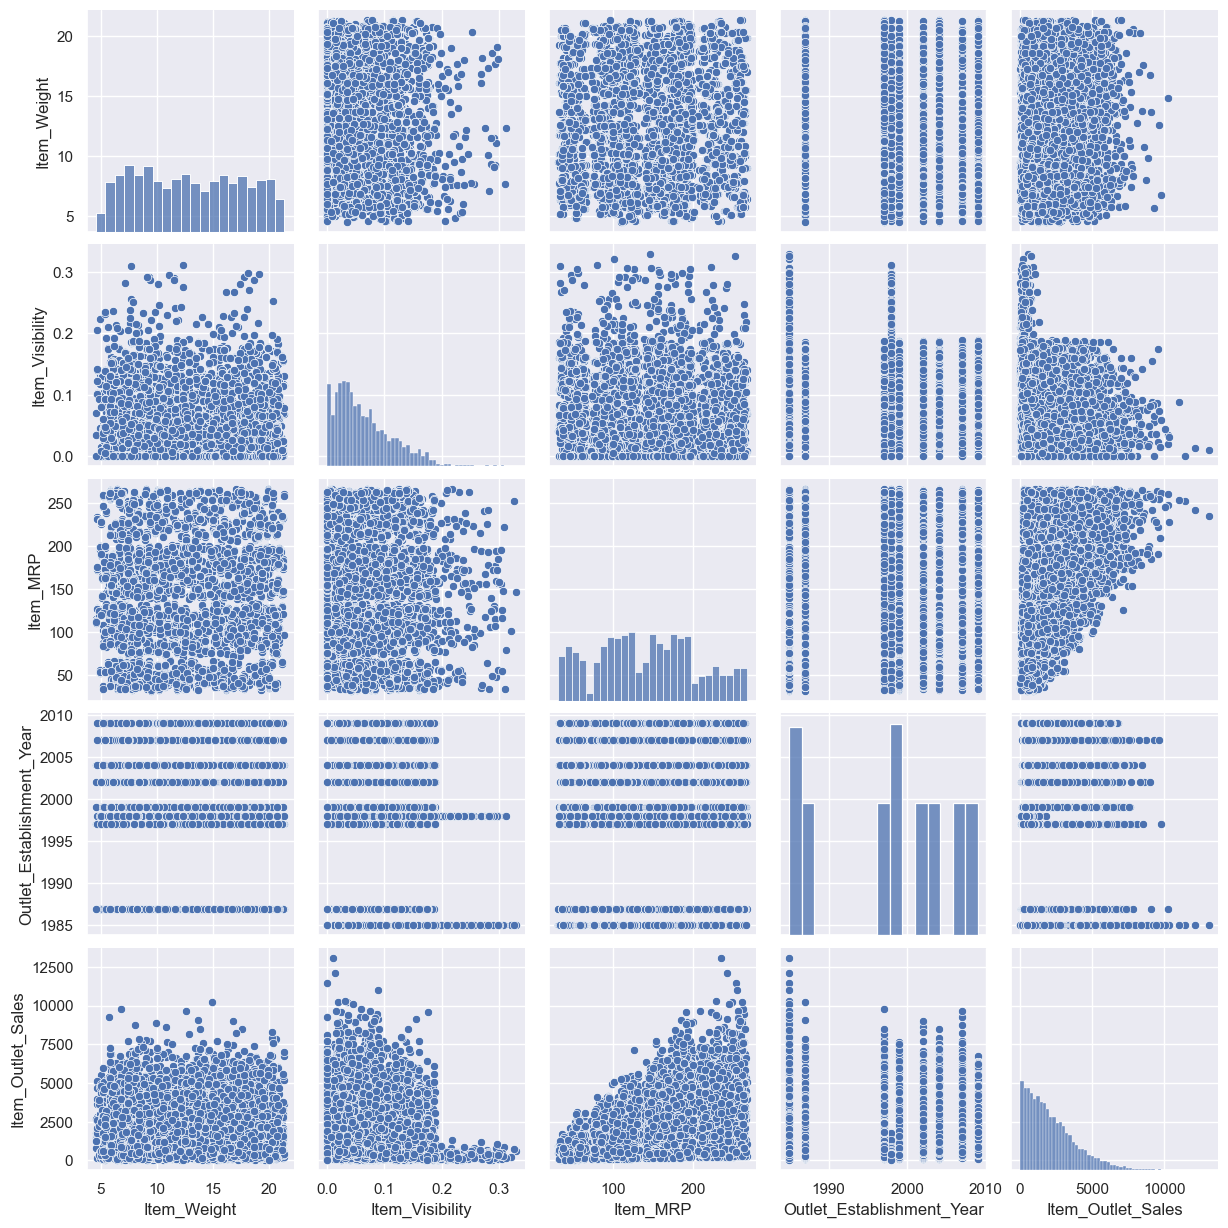

In [6]:
sns.pairplot(df)

## Missing Data and Data Cleaning

In [7]:
df.isnull()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

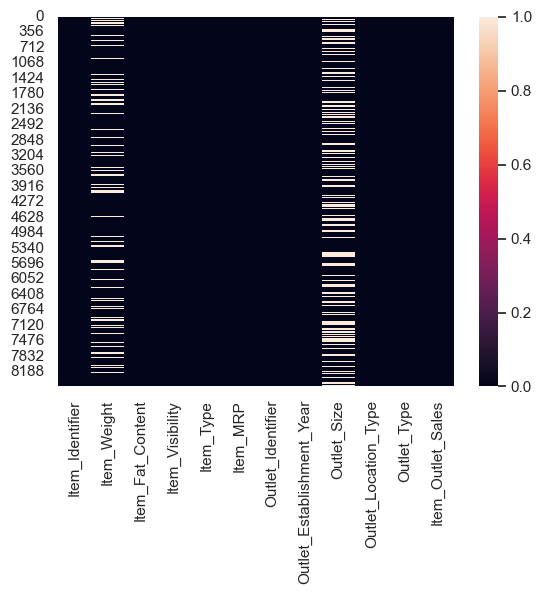

In [8]:
sns.heatmap(df.isnull())

In [9]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Show the unique values ​​for each categorical variable
for col in categorical_cols:
    print(f"----- {col} -----")
    print(df[col].unique())
    print("\n")


----- Item_Identifier -----
['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']


----- Item_Fat_Content -----
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


----- Item_Type -----
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']


----- Outlet_Identifier -----
['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027' 'OUT045' 'OUT017' 'OUT046'
 'OUT035' 'OUT019']


----- Outlet_Size -----
['Medium' nan 'High' 'Small']


----- Outlet_Location_Type -----
['Tier 1' 'Tier 3' 'Tier 2']


----- Outlet_Type -----
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']




In [10]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categories")


Item_Identifier: 1559 categories
Item_Fat_Content: 5 categories
Item_Type: 16 categories
Outlet_Identifier: 10 categories
Outlet_Size: 3 categories
Outlet_Location_Type: 3 categories
Outlet_Type: 4 categories


In [11]:
# Create a new cleaned column
df['Item_Fat_Content_Clean'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

# Check the unique values after cleaning
print(df['Item_Fat_Content_Clean'].unique())



['Low Fat' 'Regular']


C:\Users\k.key B\AppData\Local\Temp\ipykernel_4740\2405805705.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Item_Type", y="Item_Weight", data=df,palette='rainbow')


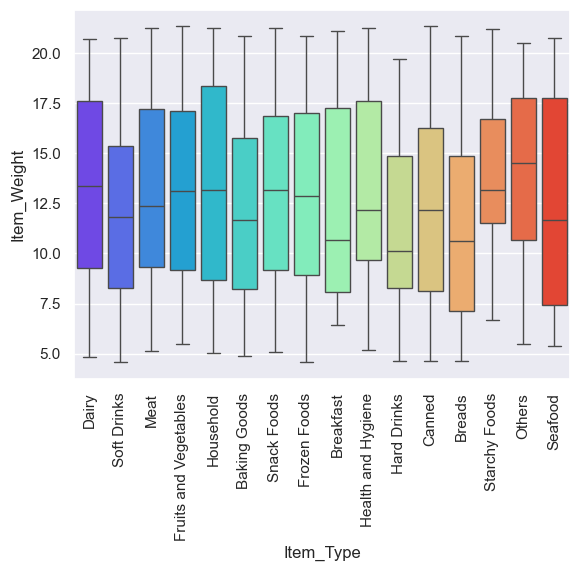

In [12]:
sns.boxplot(x="Item_Type", y="Item_Weight", data=df,palette='rainbow')
plt.xticks(rotation=90) 
plt.show()

Since the Item_Weight distribution varies across different Item_Type categories, this variable can be used to impute missing values. Given the non-normal distributions, the median weight per Item_Type is the most appropriate measure for imputation

C:\Users\k.key B\AppData\Local\Temp\ipykernel_4740\2247448075.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Item_Fat_Content_Clean", y="Item_Weight", data=df,palette='rainbow')


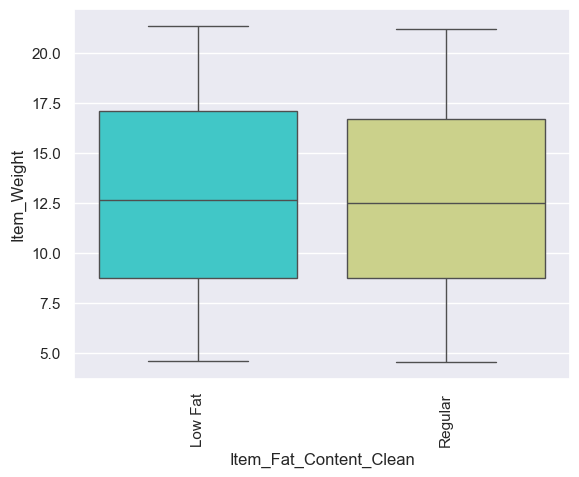

In [13]:
sns.boxplot(x="Item_Fat_Content_Clean", y="Item_Weight", data=df,palette='rainbow')
plt.xticks(rotation=90) 
plt.show()

Since the mean values for both groups are very similar, this categorical variable does not need to be considered when handling missing values in Item_Weight

In [14]:
df.groupby("Item_Type")['Item_Weight'].median()

Item_Type
Baking Goods             11.650
Breads                   10.600
Breakfast                10.695
Canned                   12.150
Dairy                    13.350
Frozen Foods             12.850
Fruits and Vegetables    13.100
Hard Drinks              10.100
Health and Hygiene       12.150
Household                13.150
Meat                     12.350
Others                   14.500
Seafood                  11.650
Snack Foods              13.150
Soft Drinks              11.800
Starchy Foods            13.175
Name: Item_Weight, dtype: float64

In [15]:
df['Item_Weight'] = df['Item_Weight'].fillna(df.groupby(["Item_Type"])['Item_Weight'].transform('median'))

<Axes: >

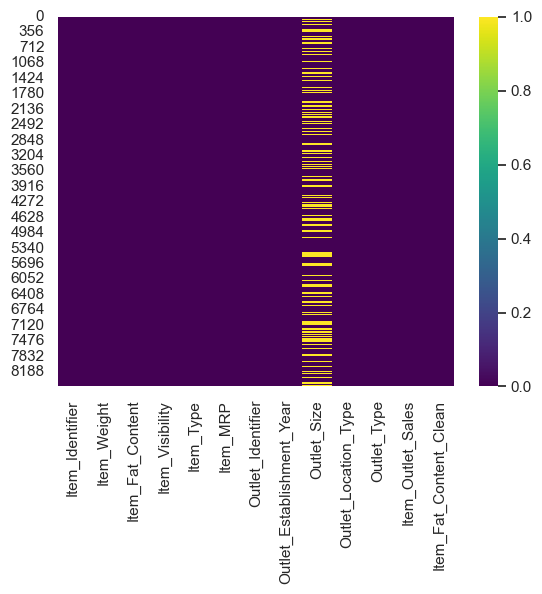

In [16]:
sns.heatmap(df.isnull(),cmap='viridis')

In [17]:
# View Outlet_Size fashion for each Outlet_Type
outlet_size_mode = (
    df.groupby('Outlet_Type')['Outlet_Size']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
)

print(outlet_size_mode)

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object


In [18]:
df.groupby(['Outlet_Location_Type','Outlet_Type', 'Outlet_Size']).size()


Outlet_Location_Type  Outlet_Type        Outlet_Size
Tier 1                Grocery Store      Small          528
                      Supermarket Type1  Medium         930
                                         Small          930
Tier 2                Supermarket Type1  Small          930
Tier 3                Supermarket Type1  High           932
                      Supermarket Type2  Medium         928
                      Supermarket Type3  Medium         935
dtype: int64

In [19]:
df.groupby(['Outlet_Location_Type', 'Outlet_Size']).size()


Outlet_Location_Type  Outlet_Size
Tier 1                Medium          930
                      Small          1458
Tier 2                Small           930
Tier 3                High            932
                      Medium         1863
dtype: int64

In [20]:
global_mode = df['Outlet_Size'].mode()[0]
print("Global mode Outlet_Size:", global_mode)

Global mode Outlet_Size: Medium


In [21]:
# Impute Outlet_Size using mode by group of Outlet_Type
df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.mode().empty else x
)


<Axes: >

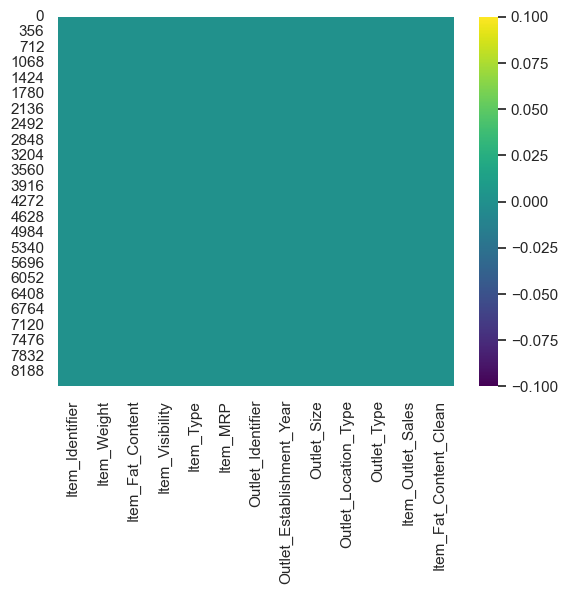

In [22]:
sns.heatmap(df.isnull(),cmap='viridis')

In [23]:
df.drop('Item_Fat_Content', axis=1, inplace=True)
df.rename(columns={'Item_Fat_Content_Clean': 'Item_Fat_Content'}, inplace=True)


In [24]:
df

,Item_Identifier,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Fat_Content
0,FDA15,9.300,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Low Fat
1,DRC01,5.920,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Regular
2,FDN15,17.500,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Low Fat
3,FDX07,19.200,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Regular
4,NCD19,8.930,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Low Fat
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,Low Fat
8519,FDS36,8.380,0.046982,Baking Goods,108.1570,OUT045,2002,Small,Tier 2,Supermarket Type1,549.2850,Regular
8520,NCJ29,10.600,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136,Low Fat
8521,FDN46,7.210,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976,Regular


In [25]:
df.drop('Item_Identifier', axis=1, inplace=True)

## Converting Categorical Features

We'll need to convert categorical features to dummy variables using pandas.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Visibility            8523 non-null   float64
 2   Item_Type                  8523 non-null   object 
 3   Item_MRP                   8523 non-null   float64
 4   Outlet_Identifier          8523 non-null   object 
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                8523 non-null   object 
 7   Outlet_Location_Type       8523 non-null   object 
 8   Outlet_Type                8523 non-null   object 
 9   Item_Outlet_Sales          8523 non-null   float64
 10  Item_Fat_Content           8523 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 732.6+ KB


In [27]:
df.head()

,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Fat_Content
0,9.30,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,Low Fat
1,5.92,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,Regular
2,17.50,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,Low Fat
3,19.20,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,Regular
4,8.93,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Low Fat


In [28]:
Item_Type = pd.get_dummies(df['Item_Type'],dtype=int,drop_first=True)
Item_Type

,Breads,Breakfast,Canned,Dairy,Frozen Foods,Fruits and Vegetables,Hard Drinks,Health and Hygiene,Household,Meat,Others,Seafood,Snack Foods,Soft Drinks,Starchy Foods
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
8519,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8520,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
8521,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [29]:
Outlet_Identifier = pd.get_dummies(df['Outlet_Identifier'],dtype=int,drop_first=True)
Outlet_Identifier

,OUT013,OUT017,OUT018,OUT019,OUT027,OUT035,OUT045,OUT046,OUT049
0,0,0,0,0,0,0,0,0,1
1,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
8518,1,0,0,0,0,0,0,0,0
8519,0,0,0,0,0,0,1,0,0
8520,0,0,0,0,0,1,0,0,0
8521,0,0,1,0,0,0,0,0,0


In [30]:
Outlet_Size = pd.get_dummies(df['Outlet_Size'],dtype=int,drop_first=True)
Outlet_Size

,Medium,Small
0,1,0
1,1,0
2,1,0
3,0,1
4,0,0
...,...,...
8518,0,0
8519,0,1
8520,0,1
8521,1,0


In [31]:
Outlet_Location_Type = pd.get_dummies(df['Outlet_Location_Type'],dtype=int,drop_first=True)
Outlet_Location_Type

,Tier 2,Tier 3
0,0,0
1,0,1
2,0,0
3,0,1
4,0,1
...,...,...
8518,0,1
8519,1,0
8520,1,0
8521,0,1


In [32]:
Outlet_Type = pd.get_dummies(df['Outlet_Type'],dtype=int,drop_first=True)
Outlet_Type

,Supermarket Type1,Supermarket Type2,Supermarket Type3
0,1,0,0
1,0,1,0
2,1,0,0
3,0,0,0
4,1,0,0
...,...,...,...
8518,1,0,0
8519,1,0,0
8520,1,0,0
8521,0,1,0


In [33]:
Item_Fat_Content = pd.get_dummies(df['Item_Fat_Content'],dtype=int,drop_first=True)
Item_Fat_Content

,Regular
0,0
1,1
2,0
3,1
4,0
...,...
8518,0
8519,1
8520,0
8521,1


In [34]:
df.drop(['Item_Type','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type',"Item_Fat_Content"],axis=1,inplace=True)
X_num=df
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.30,0.016047,249.8092,1999,3735.1380
1,5.92,0.019278,48.2692,2009,443.4228
2,17.50,0.016760,141.6180,1999,2097.2700
3,19.20,0.000000,182.0950,1998,732.3800
4,8.93,0.000000,53.8614,1987,994.7052


In [35]:
df = pd.concat([df,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Fat_Content],axis=1)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Visibility            8523 non-null   float64
 2   Item_MRP                   8523 non-null   float64
 3   Outlet_Establishment_Year  8523 non-null   int64  
 4   Item_Outlet_Sales          8523 non-null   float64
 5   Breads                     8523 non-null   int64  
 6   Breakfast                  8523 non-null   int64  
 7   Canned                     8523 non-null   int64  
 8   Dairy                      8523 non-null   int64  
 9   Frozen Foods               8523 non-null   int64  
 10  Fruits and Vegetables      8523 non-null   int64  
 11  Hard Drinks                8523 non-null   int64  
 12  Health and Hygiene         8523 non-null   int64  
 13  Household                  8523 non-null   int64

In [37]:
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Breads,Breakfast,Canned,Dairy,Frozen Foods,...,OUT046,OUT049,Medium,Small,Tier 2,Tier 3,Supermarket Type1,Supermarket Type2,Supermarket Type3,Regular
0,9.30,0.016047,249.8092,1999,3735.1380,0,0,0,1,0,...,0,1,1,0,0,0,1,0,0,0
1,5.92,0.019278,48.2692,2009,443.4228,0,0,0,0,0,...,0,0,1,0,0,1,0,1,0,1
2,17.50,0.016760,141.6180,1999,2097.2700,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
3,19.20,0.000000,182.0950,1998,732.3800,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
4,8.93,0.000000,53.8614,1987,994.7052,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0


# PCA

In [38]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [39]:
#Data scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

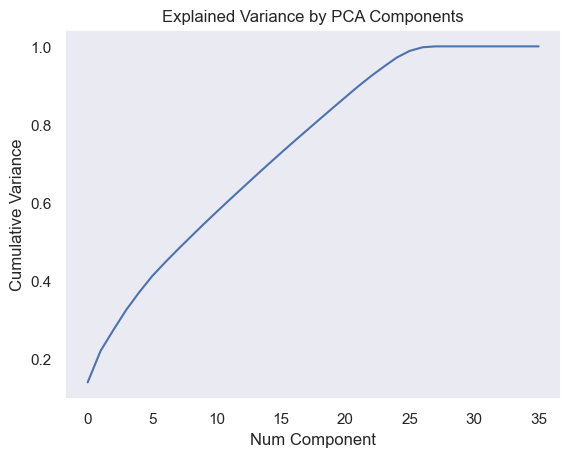

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)


plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Num Component')
plt.ylabel('Cumulative Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()


In [41]:
pca = PCA(0.90)
X_pca = pca.fit_transform(X_scaled)
pca.n_components_

np.int64(23)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.5131952861965665
RMSE: 1150.2698120031025


In [44]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 865.1206852336533
MSE: 1323120.6404056526
RMSE: 1150.2698120031025


### PCA and Linear Regression Results

After applying **PCA** and retaining **90% of the variance**, the dataset was reduced to **23 principal components**.  
Using these components in a **Linear Regression** model produced the following metrics:

- **R²:** 0.51 → The model explains about 51% of the variance in the target variable.  
- **RMSE:** 1150.27 → Indicates a relatively high prediction error.

These results suggest that while PCA effectively reduced dimensionality, the **linear relationship between predictors and the target variable is only moderate**.  
To improve performance, it may be beneficial to explore **non-linear models** (e.g., Random Forest, Gradient Boosting).

## QUESTION 2

### The SMS Spam Collection is a set of SMS tagged messages that have been collected from SMS Spam research database. It contains one set of SMS messages in English of 5,572 messages, tagged acording being ham (legitimate) or spam.

### Out of the 5572 sets of sms messages, approximately 20% of the messages have been trimmed and kept aside for Evaluating your model by the Instructor. You only have 4458 rows to build your model. Rest will be used by the instructor as a blind evaluation of your model. This data is not provided to you.

### Use this dataset to build a prediction model as follows that will accurately classify which texts are spam?

### 1. Use Count vectorizer to convert the texts into numerical values. Make sure to perform EDA first to check for any issues with the data.  **[5 Marks]**

### 2. Use Logistic Regression with L2 Regularisation (using your intelligent choice of Hyperparameters), find the accuracy/precison/recall of SPAM/HAM detection. Analyze your results and provide what could improve your results. **[10 Marks]**

### 3. Compare your result with Random Forest Classifier for this same dataset. (using your intelligent choice of Hyperparameters).**[5 Marks]**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

%matplotlib inline

df = pd.read_csv("spamham.csv")  # replace with actual file
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4457 entries, 0 to 4456
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  4457 non-null   object
 1   Message   4457 non-null   object
dtypes: object(2)
memory usage: 69.8+ KB


,Category,Message
count,4457,4457
unique,2,4157
top,ham,"Sorry, I'll call later"
freq,3863,26


In [46]:
col_map = {c.lower(): c for c in df.columns}
label_col  = col_map.get("category", col_map.get("v1", list(df.columns)[0]))
text_col   = col_map.get("message",  col_map.get("v2", list(df.columns)[1]))

In [47]:
RANDOM_STATE = 42
DATA_PATH = "spamham.csv"

df = df[[label_col, text_col]].dropna().drop_duplicates()
df.columns = ["label", "text"]

print("\n=== EDA ===")
print("Shape:", df.shape)
print("Missing total:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Class balance:\n", df["label"].value_counts())
df["len"] = df["text"].astype(str).str.len()
print("\nLength stats:\n", df["len"].describe())

# ============== 1) Train / test split ==============
y = df["label"].str.lower().map({"ham":0, "spam":1}).astype(int).values
X = df["text"].astype(str).values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)


=== EDA ===
Shape: (4157, 2)
Missing total: 0
Duplicates: 0
Class balance:
 label
ham     3635
spam     522
Name: count, dtype: int64

Length stats:
 count    4157.000000
mean       79.432523
std        59.304106
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: len, dtype: float64


In [48]:
countvec = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),  # unigrams + bigrams help on this dataset
    min_df=2,
    binary=True,        # binary features work nicely for LR with SMS
    max_features=3000   # cap dimensionality (also helps RF)
)

In [49]:
X_train_vec = countvec.fit_transform(X_train)
X_test_vec  = countvec.transform(X_test)

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1500,
    random_state=RANDOM_STATE
)
param_grid_lr = {"C": [0.5, 1.0, 3.0, 10.0]}
gs_lr = GridSearchCV(lr, param_grid_lr, scoring="f1", cv=cv, n_jobs=-1, verbose=0)
gs_lr.fit(X_train_vec, y_train)

lr_best = gs_lr.best_estimator_
y_pred_lr = lr_best.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test, y_pred_lr, average="binary", zero_division=0
)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\n=== Logistic Regression (L2, CountVectorizer) ===")
print("Best params:", gs_lr.best_params_)
print(f"Accuracy: {acc_lr:.4f} | Precision(spam): {prec_lr:.4f} | Recall(spam): {rec_lr:.4f} | F1(spam): {f1_lr:.4f}")
print("Confusion matrix (rows=true, cols=pred):\n", pd.DataFrame(cm_lr,
      index=["True ham","True spam"], columns=["Pred ham","Pred spam"]))
print("\nClassification report:\n",
      classification_report(y_test, y_pred_lr, target_names=["ham","spam"], zero_division=0))


=== Logistic Regression (L2, CountVectorizer) ===
Best params: {'C': 0.5}
Accuracy: 0.9844 | Precision(spam): 0.9596 | Recall(spam): 0.9135 | F1(spam): 0.9360
Confusion matrix (rows=true, cols=pred):
            Pred ham  Pred spam
True ham        724          4
True spam         9         95

Classification report:
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       728
        spam       0.96      0.91      0.94       104

    accuracy                           0.98       832
   macro avg       0.97      0.95      0.96       832
weighted avg       0.98      0.98      0.98       832



In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np
import pandas as pd

# 1) Dense matrices (RF handles dense better for many features)
X_train_dense = X_train_vec.toarray()
X_test_dense  = X_test_vec.toarray()

# 2) CV + compact hyperparameter grid (good tradeoff for this dataset size)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42, n_jobs=3, class_weight="balanced",
                            max_samples=0.8,       # subsample each tree to reduce cost
                            bootstrap=True)

param_grid_rf = {
    "n_estimators": [150, 250],         # more trees → stabler metrics
    "max_depth": [None, 40],        # None lets trees grow fully; 30/60 control overfitting
    "min_samples_split": [2],        # regularization
    "min_samples_leaf": [1, 2],         # regularization
    "max_features": ["sqrt", 0.25]      # feature subsampling (sqrt is standard)
}

gs_rf = GridSearchCV(rf, param_grid_rf, scoring="f1", cv=cv, n_jobs=3, verbose=0)
gs_rf.fit(X_train_dense, y_train)

rf_best = gs_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_dense)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average="binary", zero_division=0
)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n=== Random Forest (CountVectorizer) ===")
print("Best params:", gs_rf.best_params_)
print(f"Accuracy: {acc_rf:.4f} | Precision(spam): {prec_rf:.4f} | Recall(spam): {rec_rf:.4f} | F1(spam): {f1_rf:.4f}")
print("Confusion matrix (rows=true, cols=pred):\n", pd.DataFrame(
      cm_rf, index=['True ham','True spam'], columns=['Pred ham','Pred spam']))
print("\nClassification report:\n",
      classification_report(y_test, y_pred_rf, target_names=["ham","spam"], zero_division=0))

# (Optional) quick side-by-side if you still have lr metrics from Point 2 in variables:
try:
    comp = pd.DataFrame([
        ["Logistic Regression (L2)", acc_lr, prec_lr, rec_lr, f1_lr],
        ["Random Forest",            acc_rf, prec_rf, rec_rf, f1_rf]
    ], columns=["Model","Accuracy","Precision(spam)","Recall(spam)","F1(spam)"])
    print("\n=== Model comparison ===\n", comp.to_string(index=False))
except NameError:
    pass


=== Random Forest (CountVectorizer) ===
Best params: {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250}
Accuracy: 0.9772 | Precision(spam): 0.9293 | Recall(spam): 0.8846 | F1(spam): 0.9064
Confusion matrix (rows=true, cols=pred):
            Pred ham  Pred spam
True ham        721          7
True spam        12         92

Classification report:
               precision    recall  f1-score   support

         ham       0.98      0.99      0.99       728
        spam       0.93      0.88      0.91       104

    accuracy                           0.98       832
   macro avg       0.96      0.94      0.95       832
weighted avg       0.98      0.98      0.98       832


=== Model comparison ===
                    Model  Accuracy  Precision(spam)  Recall(spam)  F1(spam)
Logistic Regression (L2)  0.984375         0.959596      0.913462  0.935961
           Random Forest  0.977163         0.929293      0.884615  0.906404


## Model Comparison

| Model | Accuracy | Precision (Spam) | Recall (Spam) | F1 (Spam) |
|:------|:----------:|:----------------:|:--------------:|:-----------:|
| **Logistic Regression (L2)** | **0.9844** | **0.9596** | **0.9135** | **0.9360** |
| **Random Forest** | 0.9772 | 0.9293 | 0.8846 | 0.9064 |

---

### Conclusion
Using CountVectorizer + Logistic Regression with L2 regularization provided the best spam detection performance on this dataset, achieving ~98% accuracy and balanced precision-recall for the spam class.

Logistic Regression generalizes better for sparse, high-dimensional text data because it learns linear decision boundaries directly from token weights.

Random Forest, while robust and capable of modeling non-linearities, is less efficient in high-dimensional sparse spaces and requires more computation time for similar or slightly lower performance.

For this dataset, Logistic Regression (L2) is the preferred model.

---
